In [25]:
import numpy as np
import json
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
from sklearn.decomposition import PCA
from numpy.linalg import norm
from tqdm import tqdm

---
## 1. We start by loading the context forest paths
> Contect Forest - All the Context Trees we generated for a `keyword` in a given `domain`

In [26]:
# Setting up path variables
PATH_output_dir = "/home/ppathak2/Hypothesis_Generation_Active_Learning/output_trees"
domain = 'medicine'
topic = 'acetaminophen_[40]'
PATH_contex_forest = os.path.join(PATH_output_dir, domain, topic)
os.path.isdir(PATH_contex_forest)

True

---
## 2. Now we must convert each `Context Tree` to its `Contexual_Embedding`

In [27]:
# Some helper functions-

def polar_normalization(vec:np.ndarray):
    min_val = np.min(vec)
    max_val = np.max(vec)
    
    if max_val == min_val:
        return np.zeros_like(vec)
    
    scaled = (vec - min_val) / (max_val - min_val)
    normalized = scaled * 2 - 1
    return normalized

def calculate_context_embedding(context_tree_embd:dict, normalize:bool=True):

    final_embedding = np.zeros_like(context_tree_embd[next(iter(context_tree_embd))]['w88_enc'])
    for keyword, values in context_tree_embd.items():
        w88_embding = np.array(values['w88_enc'])
        if (np.isnan(w88_embding).any() or np.isinf(w88_embding).any()):
            continue
        if normalize:
            w88_embding = polar_normalization(w88_embding)

        ## TODO: Ensure the heirarchal_embedding_pipeline resolves these issues-
        if (w88_embding.shape[0] > 1):
            w88_embding = w88_embding[0, :].reshape(1, w88_embding.shape[-1])
        if (len(w88_embding) == 0):
            w88_embding = np.zeros_like(final_embedding)
        final_embedding += w88_embding

    return final_embedding

#### > The variable `Contextual_Forest` contains the embeddings of each `Context Tree` from the `Context Forest`

In [28]:
def get_context_forest(PATH_contex_forest:str):
    runs = os.listdir(PATH_contex_forest)
    runs.remove('LOG_failed_responses.json')
    Contextual_Forest = np.random.rand(len(runs), 768)
    for i, run_num in tqdm(enumerate(runs), total=len(runs)):
        if (run_num == 'LOG_failed_responses.json'):
            continue
        PATH_tree = os.path.join(PATH_contex_forest, run_num, 'embdng_tree_v2.json')
        with open(PATH_tree, 'r') as f:
            emdng_context_tree = json.load(f)

        final_embedding = calculate_context_embedding(emdng_context_tree, normalize=False)
        Contextual_Forest[i, :] = final_embedding
    return Contextual_Forest

In [29]:
Contextual_Forest = get_context_forest(PATH_contex_forest)
Contextual_Forest.shape

100%|██████████| 200/200 [00:03<00:00, 53.73it/s]


(200, 768)

---
## 3. Now we calculate the `Centroid` of the `Context Forest` - `Context_Forest_Centroid`

In [30]:
emb_sum = np.sum(Contextual_Forest, axis=0)
Context_Forest_Centroid = emb_sum/Contextual_Forest.shape[-1]
Context_Forest_Centroid.shape

(768,)

---
## 4. Cosine Distance-
###     4.1. Calculating the cosine distance between `Context_Forest_Centroid` and each `Contexual Embedding`

In [31]:
Context_Forest_Centroid = Context_Forest_Centroid.squeeze()
Context_Forest_Centroid.shape

(768,)

In [32]:
# Compute dot products-
dot_products = np.dot(Contextual_Forest, Context_Forest_Centroid)

# Compute norms-
Contextual_Forest_norms = norm(Contextual_Forest, axis=1)
Context_Forest_Centroid_norm = norm(Context_Forest_Centroid)

# Cosine similarities-
cosine_similarities = dot_products / (Contextual_Forest_norms * Context_Forest_Centroid_norm)

# Cosine distances
cosine_distances = 1 - cosine_similarities
cosine_distances.shape

(200,)

### 4.2. Plotting the Cosine Distances Distribution using Sanket's Code-

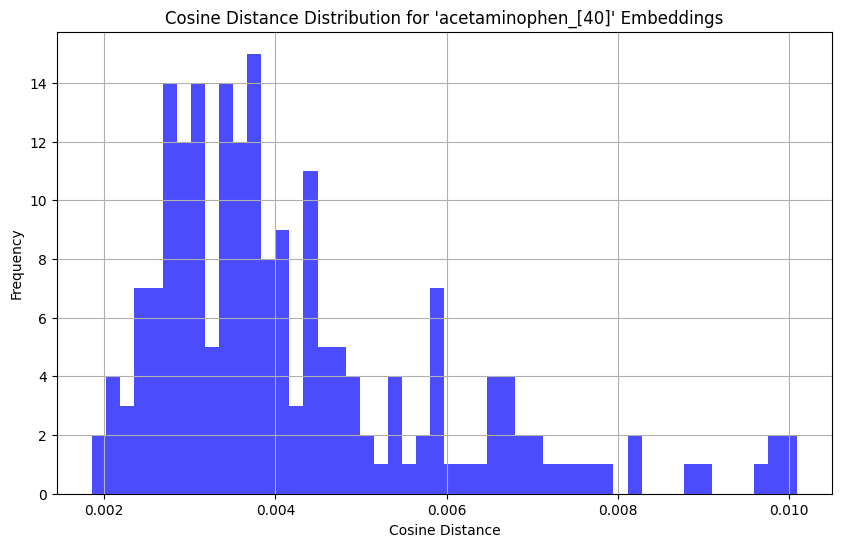

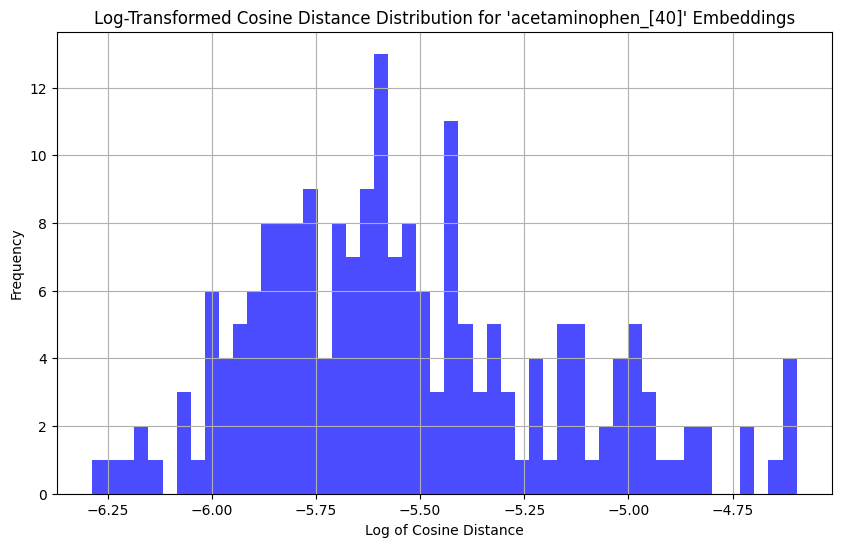

In [33]:
# Collecting cosine distances for visualization

# Plotting histogram of cosine distances
plt.figure(figsize=(10, 6))
plt.hist(cosine_distances, bins=50, color='blue', alpha=0.7)
plt.title(f"Cosine Distance Distribution for '{topic}' Embeddings")
plt.xlabel("Cosine Distance")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

import numpy as np
import matplotlib.pyplot as plt

# Collecting cosine distances for visualization

# Taking the log of cosine distances
log_cosine_distances = np.log(cosine_distances)

# Plotting histogram of log-transformed cosine distances
plt.figure(figsize=(10, 6))
plt.hist(log_cosine_distances, bins=50, color='blue', alpha=0.7)
plt.title(f"Log-Transformed Cosine Distance Distribution for '{topic}' Embeddings")
plt.xlabel("Log of Cosine Distance")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

---
## 5. Further insights-

Mean (μ) of cosine distances: 0.004233723059418573
Standard Deviation (σ) of cosine distances: 0.0017127316358839816
Maximum cosine distance: 0.010088898667512392
Minimum cosine distance: 0.001860292137850883
Difference between max and min: 0.008228606529661509
Means (μ) of the three Gaussians: [0.00381041 0.00720502 0.00507885]
Difference between max μ and min μ: 0.0033946046606771487


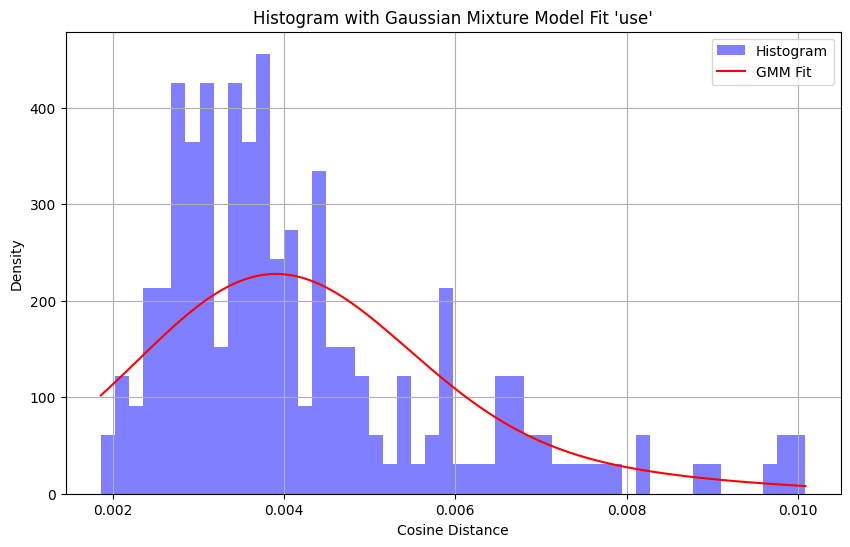

In [34]:
# Converting to a NumPy array for easier calculations
cosine_distances = np.array(cosine_distances)

# Calculating mean (μ) and standard deviation (σ)
mean_cosine_distance = np.mean(cosine_distances)
std_dev_cosine_distance = np.std(cosine_distances)

# Finding max and min cosine distances
max_cosine_distance = np.max(cosine_distances)
min_cosine_distance = np.min(cosine_distances)

# Calculating the difference between max and min
max_min_difference = max_cosine_distance - min_cosine_distance

# Printing the results
print(f"Mean (μ) of cosine distances: {mean_cosine_distance}")
print(f"Standard Deviation (σ) of cosine distances: {std_dev_cosine_distance}")
print(f"Maximum cosine distance: {max_cosine_distance}")
print(f"Minimum cosine distance: {min_cosine_distance}")
print(f"Difference between max and min: {max_min_difference}")

from sklearn.mixture import GaussianMixture
import numpy as np
import matplotlib.pyplot as plt

cosine_distances = np.array(cosine_distances).reshape(-1, 1)  # Reshape for GMM input

# Step 1: Fit Gaussian Mixture Model with 3 components
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(cosine_distances)
gmm.weights_

# # Step 2: Extract the means (μ) of the two Gaussian distributions
# means = gmm.means_.flatten()
# print(f"Means (μ) of the two Gaussians: {means}")

# # Calculate the distance between the two means
# mean_distance = abs(means[1] - means[0])
# print(f"Distance between μ2 and μ1: {mean_distance}")

# Step 2: Extract the means (μ) of the three Gaussian distributions
means = gmm.means_.flatten()
print(f"Means (μ) of the three Gaussians: {means}")

# Calculate the difference between the maximum and minimum means
mean_difference = max(means) - min(means)
print(f"Difference between max μ and min μ: {mean_difference}")


# Step 3: Plot the GMM over the histogram
plt.figure(figsize=(10, 6))
plt.hist(cosine_distances, bins=50, color='blue', alpha=0.5, density=True, label="Histogram")

# Plot the two Gaussian distributions
x = np.linspace(cosine_distances.min(), cosine_distances.max(), 1000).reshape(-1, 1)
log_prob = gmm.score_samples(x)
pdf = np.exp(log_prob)

plt.plot(x, pdf, color='red', label="GMM Fit")
plt.title("Histogram with Gaussian Mixture Model Fit 'use'")
plt.xlabel("Cosine Distance")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

---
## Now testing the following keywords-
* acetaminophen
* gliosis
* Leukemia
* Dalfopristin

In [35]:
def plot_graphs(cosine_distances, keyword):
    # Safe log transform to avoid log(0)
    log_cosine_distances = np.log(cosine_distances + 1e-10)

    # Set up subplots: 1 row, 2 columns
    fig, axes = plt.subplots(2, 1, figsize=(18, 10))

    # First row: two histograms side by side
    hist_axes = fig.add_subplot(2, 1, 1)
    fig.subplots_adjust(hspace=0.5)
    fig.delaxes(axes[1])  # Remove the second axes so we can add a custom one for text

    # Create subplots manually for histograms
    ax1 = plt.subplot(1, 2, 1)
    ax2 = plt.subplot(1, 2, 2)

    # Plot 1: Raw cosine distance
    ax1.hist(cosine_distances, bins=50, color='orange', alpha=0.7)
    ax1.set_title(f"Cosine Distance Distribution for '{keyword.split('_')[0]}'")
    ax1.set_xlabel("Cosine Distance")
    ax1.set_ylabel("Frequency")
    ax1.grid(True)

    # Plot 2: Log-transformed cosine distance
    ax2.hist(log_cosine_distances, bins=50, color='blue', alpha=0.7)
    ax2.set_title(f"Log(Cosine Distance) for '{keyword.split('_')[0]}'")
    ax2.set_xlabel("Log of Cosine Distance")
    ax2.set_ylabel("Frequency")
    ax2.grid(True)

    # Bottom row: Stats box
    mean_cosine_distance = np.mean(cosine_distances)
    std_dev_cosine_distance = np.std(cosine_distances)
    max_cosine_distance = np.max(cosine_distances)
    min_cosine_distance = np.min(cosine_distances)

    stats_text = (
        f"Mean Cosine Distance: {mean_cosine_distance:.4f}"
        f"Standard Deviation: {std_dev_cosine_distance:.4f}\n"
        f"Max Cosine Distance: {max_cosine_distance:.4f}"
        f"Min Cosine Distance: {min_cosine_distance:.4f}"
    )

    # Add a new axis to hold the stats textbox
    stats_ax = fig.add_axes([0.1, 0.05, 0.8, 0.15])  # [left, bottom, width, height]
    stats_ax.axis('off')
    stats_ax.text(0.5, 0.5, stats_text, fontsize=12, ha='center', va='center', family='monospace')

    plt.tight_layout(rect=[0, 0.15, 1, 1])  # Leave space for stats box
    plt.show()

In [36]:
# Starting by defining paths
# Setting up path variables
PATH_output_dir = "/home/ppathak2/Hypothesis_Generation_Active_Learning/output_trees"
domain = 'of your choice'
PATH_domain = os.path.join(PATH_output_dir, domain)
topics = os.listdir(PATH_domain)

final_analysis = {}

for topic in topics:
    PATH_topic = os.path.join(PATH_domain, topic)
    PATH_contex_forest = os.path.join(PATH_output_dir, domain, topic)

    # Load the context forest-
    Contextual_Forest = get_context_forest(PATH_contex_forest)

    # Now calculate the centroid of the forest-
    emb_sum = np.sum(Contextual_Forest, axis=0)
    Context_Forest_Centroid = emb_sum/Contextual_Forest.shape[-1]

    # Now get the cosine distances-
    Context_Forest_Centroid = Context_Forest_Centroid.squeeze()
    dot_products = np.dot(Contextual_Forest, Context_Forest_Centroid)
    # Compute norms-
    Contextual_Forest_norms = norm(Contextual_Forest, axis=1)
    Context_Forest_Centroid_norm = norm(Context_Forest_Centroid)
    # Cosine similarities-
    cosine_similarities = dot_products / (Contextual_Forest_norms * Context_Forest_Centroid_norm)
    # Cosine distances
    cosine_distances = 1 - cosine_similarities

    # Calcualte Mean, Min, Max, Std-Div of centroid space and plot histograms-
    plot_graphs(cosine_distances, topic)

ValueError: list.remove(x): x not in list